# Part 5 walkthrough — independent evaluation

`run_part5.py` computes everything in this notebook, and all the logic is in `part5.py`. Every fit and checkpoint selection (Parts 3–4) finishes before any evaluation path is generated.

**Design**
* Each case and start gets 50,000 fresh paths (seed $4000+10c+a$, batches of 5,000).
* The same paths are used for LS, NN and the reference boundary applied as a hard rule. Differences between policies are therefore **paired**, and their SEs are much smaller than the SE of each price.
* Everything is float64.

In [1]:
import pandas as pd, numpy as np
pd.set_option("display.width", 180)
from IPython.display import Image

## 1. Prices and the upper bound

A frozen rule is one admissible stopping time, so $E[Q]\le V_{\delta,N}(0,S_0)$. We check that no fitted mean sits significantly above the reference, using $z=(\text{mean}-V^{ref})/\text{SE}$. At $S_0=60$ every path exercises immediately, so the SE is about 0 and $z$ is undefined (NaN).

In [2]:
p = pd.read_csv("tables/p5_prices.csv")
display(p[["case","S0","method","mean","se","lo","hi","ref_value","z_vs_ref"]])
print("largest z among fitted policies:", p[p.method.isin(["LS","NN"])].z_vs_ref.max())

,case,S0,method,mean,se,lo,hi,ref_value,z_vs_ref
0,0,60.0,LS,40.000000,0.000000,40.000000,40.000000,40.000000,NaN
1,0,60.0,NN,40.000000,0.000000,40.000000,40.000000,40.000000,NaN
2,0,60.0,ref-boundary policy,40.000000,0.000000,40.000000,40.000000,40.000000,NaN
3,0,80.0,LS,20.661120,0.055753,20.551845,20.770395,20.868793,-3.724887
4,0,80.0,NN,20.632064,0.056300,20.521717,20.742411,20.868793,-4.204805
5,0,80.0,ref-boundary policy,20.843846,0.044744,20.756147,20.931544,20.868793,-0.557545
6,0,100.0,LS,8.639783,0.049986,8.541810,8.737757,8.807841,-3.362058
7,0,100.0,NN,8.623239,0.050127,8.524990,8.721488,8.807841,-3.682669
8,0,100.0,ref-boundary policy,8.773429,0.044760,8.685700,8.861158,8.807841,-0.768801
9,1,60.0,LS,40.000000,0.000000,40.000000,40.000000,40.000000,NaN


largest z among fitted policies: -0.3687137627224957


In [3]:
pp = pd.read_csv("tables/p5_paired.csv")
display(pp.pivot_table(index=["case","S0"], columns="pair", values="mean_diff").round(4))

pair        LS - NN  LS - ref-boundary policy  NN - ref-boundary policy
case S0                                                                
0    60.0    0.0000                    0.0000                    0.0000
     80.0    0.0291                   -0.1827                   -0.2118
     100.0   0.0165                   -0.1336                   -0.1502
1    60.0    0.0000                    0.0000                    0.0000
     80.0   -0.0117                   -0.0242                   -0.0125
     100.0  -0.0051                   -0.0436                   -0.0385
2    60.0    0.0000                    0.0000                    0.0000
     80.0   -0.0321                   -0.2485                   -0.2164
     100.0  -0.0078                   -0.1289                   -0.1211
3    60.0    0.0450                    0.0000                   -0.0450
     80.0    0.0597                   -0.0229                   -0.0827
     100.0   0.0031                   -0.0232                   -0.0263

## 2. Boundary accuracy, and how much the optimum moves with $N$

$E_{mean}$ and $E_{max}$ compare each method with the reference **for the same $N$**. `p5_N_effect` measures how much the *optimal* boundary moves between $N=180$ and $360$. That movement is the yardstick for reading a fitted method's change with $N$.

In [4]:
display(pd.read_csv("tables/p5_boundary_errors.csv"))
display(pd.read_csv("tables/p5_N_effect.csv"))

,case,N,delta,method,E_mean,E_max,j_at_max
0,0,180,0.0000,LS,0.068712,0.203524,177
1,0,180,0.0000,NN,0.071753,0.222223,179
2,1,180,0.0125,LS,0.033892,0.237071,152
3,1,180,0.0125,NN,0.017418,0.155077,170
4,2,360,0.0000,LS,0.063876,0.218541,359
5,2,360,0.0000,NN,0.061941,0.219736,359
6,3,360,0.0125,LS,0.037156,0.291560,300
7,3,360,0.0125,NN,0.042552,0.172694,296


,delta,E_mean_ref360_vs_ref180,E_max_ref360_vs_ref180
0,0.0000,0.002561,0.003062
1,0.0125,0.000783,0.003062


## 3. Perturbation (case 3, $S_0=100$)

$b^{(a)}_j=\min\{U_j,\max\{0,\hat b^{NN}_j+aK\}\}$, evaluated on the same evaluation paths.

The extra columns explain the mechanism:
* how much of the shift survives the cap and the floor;
* how many paths actually change their stopping time;
* in which direction the stopping time moves.

The finer sweep is supplementary; it is not required by the assignment.

,case,S0,a,mean_Q,se_Q,mean_diff,se_diff,applied_shift_mean,cap_binds_dates,floor_binds_dates,frac_paths_changed,frac_earlier,frac_later,mean_diff_changed
0,3,100.0,-0.02,10.090329,0.052843,0.021844,0.010517,-0.019712,0,12,0.21810,0.00000,0.2181,0.100155
1,3,100.0,0.00,10.068485,0.051622,0.000000,0.000000,0.000000,0,0,0.00000,0.00000,0.0000,0.000000
2,3,100.0,0.02,10.052324,0.050235,-0.016160,0.011424,0.013424,148,0,0.23896,0.23896,0.0000,-0.067628


,a,mean_diff,se_diff,applied_shift_mean,frac_paths_changed,cap_binds_dates
0,-0.08,0.001589,0.018965,-0.074905,0.34752,0
1,-0.07,0.003631,0.018105,-0.066079,0.33138,0
2,-0.06,0.005533,0.017055,-0.057112,0.31322,0
3,-0.05,0.005438,0.015973,-0.048001,0.29300,0
4,-0.04,-0.000377,0.014550,-0.038738,0.27274,0
5,-0.03,0.007622,0.012837,-0.029307,0.25052,0
6,-0.02,0.021844,0.010517,-0.019712,0.21810,0
7,-0.01,0.018280,0.007506,-0.009945,0.15372,0
8,0.00,0.000000,0.000000,0.000000,0.00000,0
9,0.01,-0.017516,0.007975,0.007261,0.16016,125


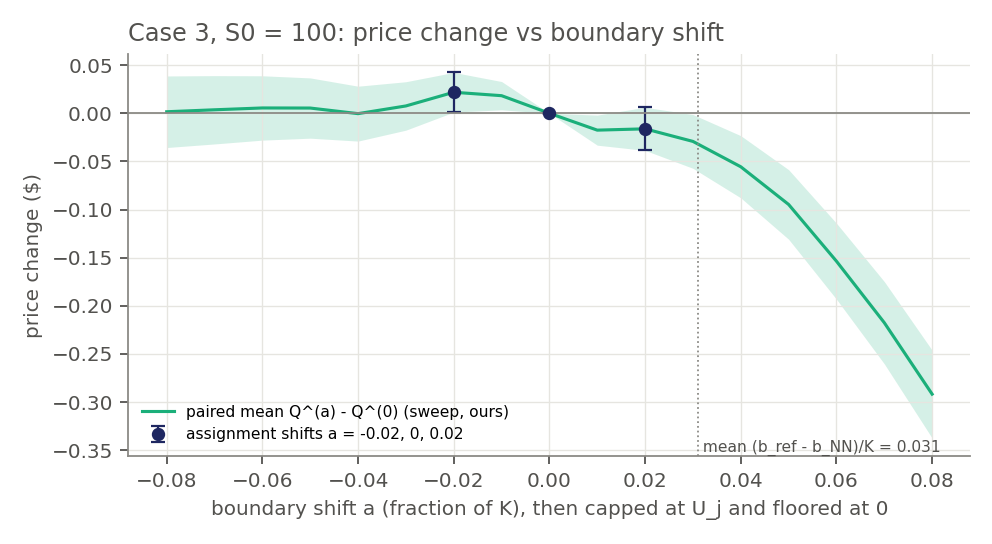

In [5]:
display(pd.read_csv("tables/p5_perturbation.csv"))
display(pd.read_csv("tables/p5_perturbation_sweep_supplementary.csv")[["a","mean_diff","se_diff","applied_shift_mean","frac_paths_changed","cap_binds_dates"]])
Image("figures/p5_perturbation.png")

## 4. Ordering diagnostics with the final policies

In [6]:
display(pd.read_csv("tables/p1_ordering_checks.csv"))

,N,method,A,B,F
0,180,LS,0.0,0.000000,0.066405
1,180,NN,21.0,0.051476,0.081677
2,180,ref,0.0,0.000000,0.000000
3,180,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000
4,360,LS,0.0,0.000000,0.093846
5,360,NN,36.0,0.051213,0.171841
6,360,ref,0.0,0.000000,0.000000
7,360,ref: max (V0 - V0.0125)^+ $,NaN,NaN,0.000000
